<a href="https://colab.research.google.com/github/keropfia/95-Confidence-and-Prediction-Intervals-ComBase-with-qPCR-data/blob/main/E.%20coli%20recovery%20Baranyi%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install lmfit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.5 MB/s eta 0:00:00


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
from lmfit import Model

In [48]:
df = pd.read_csv('/content/E. coli 0h std 6h.csv')
print(df)

    Time (h)    logN A    logN B    logN C  logN average     STDEV  Unnamed: 6
0          0  4.605950  4.517390  5.022093      4.715144  0.269488         NaN
1          1  4.163633  4.875585  4.679872      4.573030  0.367805         NaN
2          2  4.768800  4.426448  4.588494      4.594581  0.171258         NaN
3          3  4.540695  3.959956  4.274697      4.258449  0.290710         NaN
4          4  4.859687  4.768560  4.009721      4.545989  0.466652         NaN
5          5  4.397848  4.624842  4.660717      4.561136  0.142544         NaN
6          6  4.409729  4.357220  4.574381      4.447110  0.113304         NaN
7          7  4.296906  4.725661  3.712052      4.244873  0.508804         NaN
8          8  3.701741  4.648511  4.652025      4.334092  0.547635         NaN
9          9  3.644567       NaN  3.852330      3.748449  0.146911         NaN
10        10  4.511144  4.184443  4.222802      4.306129  0.178581         NaN
11        11  4.804886  4.758183  4.576583      4.71

In [65]:
def baranyi_dmfit(t, y0, y_end, umax, lag):
    """
    Baranyi growth model in log10 scale (DMFit-compatible)

    Parameters
    ----------
    t : time (h)
    y0 : initial log10 population
    y_end : final log10 population
    umax : maximum growth rate (log10 units per hour)
    lag : lag time (h)
    """
    ln10 = np.log(10.0)
    t = np.array(t)
    numerator = -1 + np.exp(ln10 * umax * lag) + np.exp(ln10 * umax * t)
    denominator = -1 + np.exp(ln10 * umax * t) + np.exp(ln10 * umax * lag) * 10 ** (y_end - y0)
    return y_end + np.log10(numerator / denominator)

In [66]:
model = Model(baranyi_dmfit)

params = model.make_params(
    y0=df['logN C'].iloc[0],              # start from first measured log10 value
    y_end=df['logN C'].max(),             # use max observed value as guess
    umax=0.8,                           # initial guess (log10/h)
    lag=11                               # initial guess for lag time (h)
)

In [67]:
params['y0'].min = 0
params['y_end'].min = params['y0'].value
params['umax'].min = 0
params['lag'].min = 0

In [68]:
result = model.fit(df['logN C'], params, t=df['Time (h)'])

In [70]:
t_smooth = np.linspace(df['Time (h)'].min(), df['Time (h)'].max(), 200)
y_pred = baranyi_dmfit(t_smooth, **result.best_values)

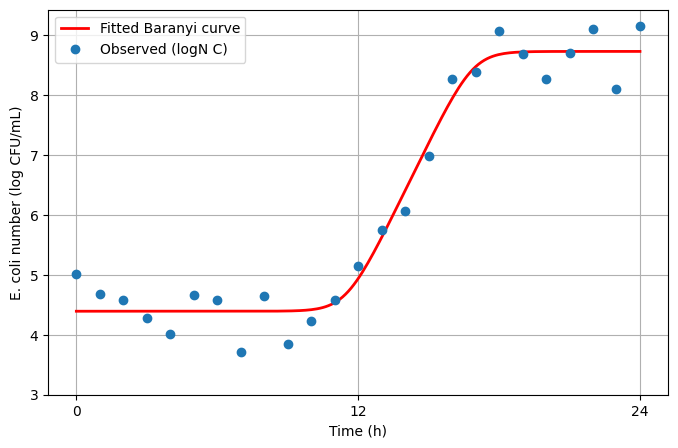

In [71]:
plt.figure(figsize=(8,5))
plt.errorbar(df['Time (h)'], df['logN C'], fmt='o', capsize=3, label='Observed (logN C)')
plt.plot(t_smooth, y_pred, 'r-', lw=2, label='Fitted Baranyi curve')
plt.xlabel('Time (h)')
plt.xticks(np.arange(0, max(t_smooth)+12, 12))
plt.ylabel('E. coli number (log CFU/mL)')
plt.yticks(np.arange(3, np.ceil(max(y_pred))+1, 1))
plt.legend()
plt.grid(True)
plt.show()


In [72]:
print(result.fit_report())

[[Model]]
    Model(baranyi_dmfit)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 36
    # data points      = 25
    # variables        = 4
    chi-square         = 3.05940846
    reduced chi-square = 0.14568612
    Akaike info crit   = -44.5163560
    Bayesian info crit = -39.6408527
    R-squared          = 0.96852021
[[Variables]]
    y0:     4.39340080 +/- 0.11419421 (2.60%) (init = 5.022093)
    y_end:  8.72966050 +/- 0.14655508 (1.68%) (init = 9.153474)
    umax:   0.80661120 +/- 0.12877939 (15.97%) (init = 0.8)
    lag:    11.5061719 +/- 0.52698371 (4.58%) (init = 11)
[[Correlations]] (unreported correlations are < 0.100)
    C(umax, lag)   = +0.8491
    C(y0, lag)     = +0.4167
    C(y_end, umax) = -0.1805
    C(y0, umax)    = +0.1416
    C(y_end, lag)  = -0.1093


Fitted curve data points

In [74]:
print("Time (t_smooth) values for the fitted curve:")
print(t_smooth)
print("\nPredicted logN (y_pred) values for the fitted curve:")
print(y_pred)

Time (t_smooth) values for the fitted curve:
[ 0.          0.12060302  0.24120603  0.36180905  0.48241206  0.60301508
  0.72361809  0.84422111  0.96482412  1.08542714  1.20603015  1.32663317
  1.44723618  1.5678392   1.68844221  1.80904523  1.92964824  2.05025126
  2.17085427  2.29145729  2.4120603   2.53266332  2.65326633  2.77386935
  2.89447236  3.01507538  3.13567839  3.25628141  3.37688442  3.49748744
  3.61809045  3.73869347  3.85929648  3.9798995   4.10050251  4.22110553
  4.34170854  4.46231156  4.58291457  4.70351759  4.8241206   4.94472362
  5.06532663  5.18592965  5.30653266  5.42713568  5.54773869  5.66834171
  5.78894472  5.90954774  6.03015075  6.15075377  6.27135678  6.3919598
  6.51256281  6.63316583  6.75376884  6.87437186  6.99497487  7.11557789
  7.2361809   7.35678392  7.47738693  7.59798995  7.71859296  7.83919598
  7.95979899  8.08040201  8.20100503  8.32160804  8.44221106  8.56281407
  8.68341709  8.8040201   8.92462312  9.04522613  9.16582915  9.28643216
  9.407